Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 6043 images belonging to 2 classes.
Found 1510 images belonging to 2 classes.


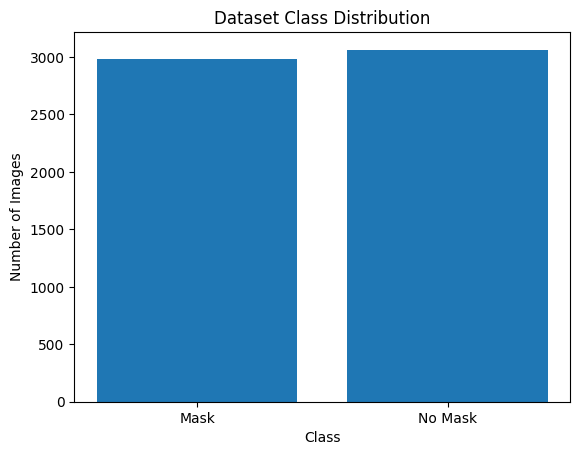

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
 38/189 ━━━━━━━━━━━━━━━━━━━━ 13:11 5s/step - accuracy: 0.6108 - loss: 0.7078

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


189/189 ━━━━━━━━━━━━━━━━━━━━ 1346s 7s/step - accuracy: 0.8317 - loss: 0.3821 - val_accuracy: 0.9113 - val_loss: 0.2451
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 266s 1s/step - accuracy: 0.8842 - loss: 0.2784 - val_accuracy: 0.9318 - val_loss: 0.2095
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 265s 1s/step - accuracy: 0.9017 - loss: 0.2458 - val_accuracy: 0.9199 - val_loss: 0.2156
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 261s 1s/step - accuracy: 0.9178 - loss: 0.2141 - val_accuracy: 0.9470 - val_loss: 0.1741
Epoch 5/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 275s 1s/step - accuracy: 0.9277 - loss: 0.1918 - val_accuracy: 0.9430 - val_loss: 0.1715
Epoch 6/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 261s 1s/step - accuracy: 0.9335 - loss: 0.1818 - val_accuracy: 0.9437 - val_loss: 0.1742
Epoch 7/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 277s 1s/step - accuracy: 0.9398 - loss: 0.1669 - val_accuracy: 0.9550 - val_loss: 0.1407
Epoch 8/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step - accuracy: 0.9421 - loss: 0.1579 - val_accuracy: 0.93

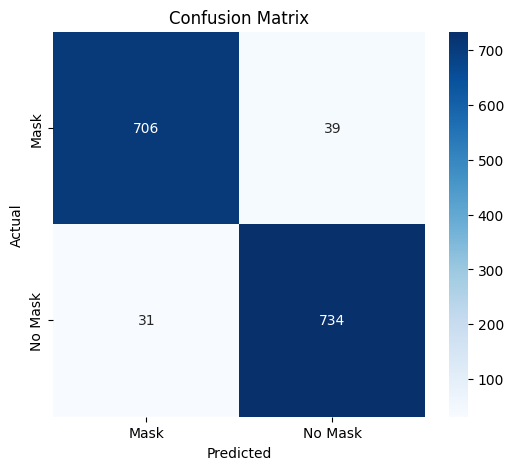

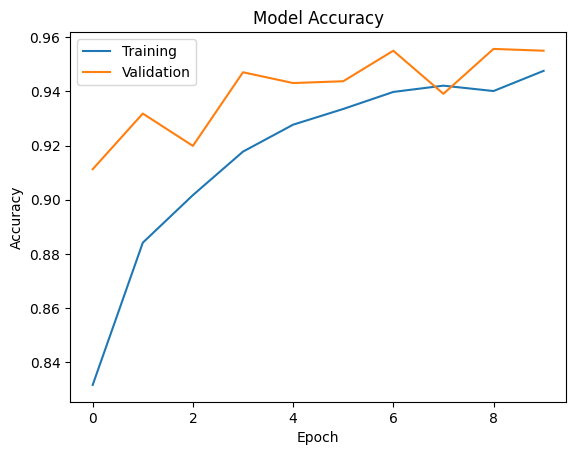

Model saved successfully


In [ ]:
# ==========================================
# 1. Mount Google Drive
# ==========================================

from google.colab import drive
drive.mount('/content/drive')


# ==========================================
# 2. Import Libraries
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix


# ==========================================
# 3. Dataset Path
# ==========================================

dataset_path = "/content/drive/MyDrive/Colab Notebooks/Mask-Detection/data"


# ==========================================
# 4. Data Preprocessing (Generator)
# ==========================================

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

test_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)


# ==========================================
# 5. Visualize Dataset Distribution
# ==========================================

class_counts = train_data.classes
unique, counts = np.unique(class_counts, return_counts=True)

plt.bar(["Mask","No Mask"], counts)
plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()


# ==========================================
# 6. Build CNN Model
# ==========================================

model = Sequential([

    Input(shape=(128,128,3)),

    Conv2D(32,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(2,activation='softmax')

])


# ==========================================
# 7. Compile Model
# ==========================================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


# ==========================================
# 8. Train Model
# ==========================================

history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)


# ==========================================
# 9. Evaluate Model
# ==========================================

loss, accuracy = model.evaluate(test_data)

print("Test Accuracy:", accuracy)


# ==========================================
# 10. Classification Report
# ==========================================

predictions = model.predict(test_data)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_data.classes

print("\nClassification Report:\n")
print(classification_report(true_classes, predicted_classes))


# ==========================================
# 11. Confusion Matrix
# ==========================================

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Mask","No Mask"],
    yticklabels=["Mask","No Mask"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


# ==========================================
# 12. Training Accuracy Graph
# ==========================================

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training","Validation"])

plt.show()


# ==========================================
# 13. Save Model (Modern Keras Format)
# ==========================================

model.save("mask_detection_model.keras")

print("Model saved successfully")

Mounted at /content/drive
Found 3087 images belonging to 2 classes.
Found 771 images belonging to 2 classes.
Previous model loaded successfully


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7583 - loss: 0.9196

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


97/97 ━━━━━━━━━━━━━━━━━━━━ 604s 6s/step - accuracy: 0.7868 - loss: 0.7622 - val_accuracy: 0.9844 - val_loss: 0.0434
Epoch 2/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 257s 3s/step - accuracy: 0.8636 - loss: 0.3864 - val_accuracy: 0.9702 - val_loss: 0.0775
Epoch 3/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 247s 3s/step - accuracy: 0.8801 - loss: 0.3137 - val_accuracy: 0.9637 - val_loss: 0.1049
Epoch 4/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 255s 3s/step - accuracy: 0.9041 - loss: 0.2597 - val_accuracy: 0.9715 - val_loss: 0.0764
Epoch 5/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - accuracy: 0.9096 - loss: 0.2264 - val_accuracy: 0.9780 - val_loss: 0.0578
Epoch 6/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 245s 3s/step - accuracy: 0.9203 - loss: 0.2082 - val_accuracy: 0.9818 - val_loss: 0.0566
Epoch 7/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 250s 3s/step - accuracy: 0.9229 - loss: 0.1874 - val_accuracy: 0.9831 - val_loss: 0.0516
Epoch 8/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 252s 2s/step - accuracy: 0.9401 - loss: 0.1540 - val_accuracy: 0.9844 - val_loss: 0.

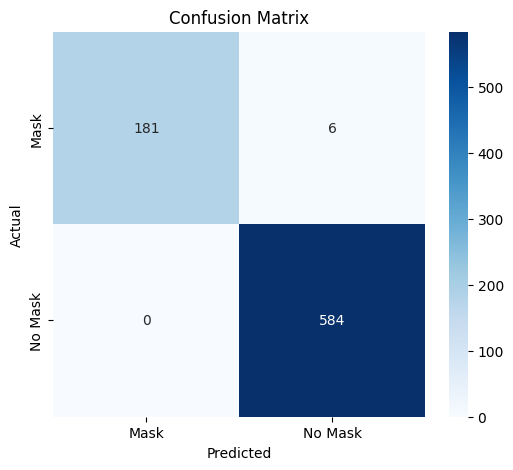

Updated model saved successfully


In [ ]:
# ==========================================
# 1. Mount Google Drive
# ==========================================

from google.colab import drive
drive.mount('/content/drive')


# ==========================================
# 2. Import Libraries
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix


# ==========================================
# 3. Dataset Path (NEW DATA)
# ==========================================

dataset_path = "/content/drive/MyDrive/Colab Notebooks/Mask-Detection/face_data"


# ==========================================
# 4. Data Generators
# ==========================================

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

test_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)


# ==========================================
# 5. Load Previously Trained Model
# ==========================================

model_path = "/content/drive/MyDrive/Colab Notebooks/Mask-Detection/mask_detection_model1.keras"

model = load_model(model_path)

print("Previous model loaded successfully")


# ==========================================
# 6. Recompile Model (Lower Learning Rate)
# ==========================================

model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


# ==========================================
# 7. Continue Training
# ==========================================

history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=15
)


# ==========================================
# 8. Evaluate Model
# ==========================================

loss, accuracy = model.evaluate(test_data)

print("Test Accuracy:", accuracy)


# ==========================================
# 9. Classification Metrics
# ==========================================

predictions = model.predict(test_data)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_data.classes

print("\nClassification Report:\n")
print(classification_report(true_classes, predicted_classes))


# ==========================================
# 10. Confusion Matrix
# ==========================================

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=["Mask","No Mask"],
    yticklabels=["Mask","No Mask"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


# ==========================================
# 11. Save Updated Model
# ==========================================

model.save("/content/drive/MyDrive/Colab Notebooks/Mask-Detection/mask_detection_model_v2.keras")

print("Updated model saved successfully")